In [1]:
from getpass import getuser # Libaray to copy things
from tempfile import NamedTemporaryFile, TemporaryDirectory 

# calculation
#import metpy.calc as mpcalc

# scipy
from scipy import stats
from scipy.ndimage import measurements
from scipy import ndimage
from scipy.optimize import curve_fit

# for plot
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter, AutoMinorLocator)
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cfeature

import easygems.healpix as egh
import healpy as hp

# basic
from pathlib import Path # Object oriented libary to deal with paths
import netCDF4 as nc
import numpy as np # Pythons standard array library
import xarray as xr # Libary to work with labeled n-dimensional data
import glob

# Functions

In [2]:
import matplotlib.colors as mcolors
def plot_map_healpix(da, ax=None, title=None, colorbar=True, cmap="viridis", nest=True, vmin=None, vmax=None, space=None, extend=None, label=None, latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    
    if not ax:
        projection = ccrs.PlateCarree(central_longitude=225)
        fig, ax = plt.subplots(
            subplot_kw={"projection": projection}, constrained_layout=True, figsize=(15, 10)
        )
    ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
    ax.coastlines()
    ax.set_title(title)
    
    # Use the range values if provided
    norm = None
    if vmin is not None and vmax is not None:
        norm = plt.Normalize(vmin, vmax)
        norm = mcolors.BoundaryNorm(np.linspace(vmin, vmax, space), cmap.N, extend=extend)

    pc = egh.healpix_show(da, ax=ax, cmap=cmap, norm=norm, nest=nest)
    
    if colorbar:
        #cbar = fig.colorbar(pc, ax=ax, orientation="horizontal", pad=0.05)
        bounds = np.linspace(vmin,vmax,space)
        pc.set_clim(vmin, vmax)
        cb = plt.colorbar(pc, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend,ticks=bounds, boundaries=bounds)
        cb.ax.set_facecolor('none')
        cb.set_label(label=label, size=15, weight='bold')
        cb.ax.tick_params(labelsize=20)
        cb.ax.set_xticklabels(bounds,rotation=270)
       # if levels is not None:
       #      cbar.set_ticks(levels)
    kw = {'levels':[-1], 'colors':['red'], 'linestyles':['solid']}
    plot_bd = AMZ_BD.plot.contour( 
                      ax=ax,
                      transform=ccrs.PlateCarree(),
                      **kw
                     )
    
    _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)
    return pc

In [3]:
def plot_monthly_maps(da, cmap="viridis", nest=True, vmin=None, vmax=None, space=None, extend=None, label=None,
                      latmin=-90, latmax=90, lonmin=-180, lonmax=180):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES

    fig, axes = plt.subplots(3, 4, figsize=(20, 25), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=225)})

    for i, ax in enumerate(axes.flat):
        month_data = da.sel(month = (i + 1))  # Select and average each month

        ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
        ax.coastlines()
        ax.set_title(f"Month {i+1}", fontsize=15, weight='bold')

        # Normalize color scale
        norm = plt.Normalize(vmin, vmax) if vmin is not None and vmax is not None else None

        # Plot data
        pc = egh.healpix_show(month_data, ax=ax, cmap=cmap, norm=norm, nest=nest)

        # Add Amazon biome contour
        kw = {'levels': [-1], 'colors': ['red'], 'linestyles': ['solid']}
        AMZ_BD.plot.contour(ax=ax, transform=ccrs.PlateCarree(), **kw)

    # Add colorbar
    cb_ax = fig.add_axes([0.25, 0.08, 0.5, 0.02])  # Colorbar position
    bounds = np.linspace(vmin, vmax, space) if space else None
    cb = plt.colorbar(pc, cax=cb_ax, orientation="horizontal", extend=extend, ticks=bounds, boundaries=bounds)
    cb.set_label(label=label, size=20, weight='bold')
    cb.ax.tick_params(labelsize=15)

    plt.tight_layout()
    plt.show()


In [4]:
def plot_map_scatter(da, title=None, colorbar=True, cmap="viridis", s=50, nest=True, vmin=None, vmax=None, space=None, extend='both', latmin=-20, latmax=20, lonmin=-80, lonmax=-40):
        dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
        AMZ_BD = dset_bd.AMAZON_BIOMES

        projection = ccrs.PlateCarree(central_longitude=225)
        coords = projection.transform_points(ccrs.Geodetic(),
                np.rad2deg(da.lon.values),np.rad2deg(da.lat.values)) 

        fig, ax = plt.subplots(figsize=(15,10),subplot_kw={'projection':projection}, constrained_layout=True)
        ax.set_extent([lonmin, lonmax, latmin, latmax], ccrs.PlateCarree())
        ax.coastlines()
        ax.set_title(title)

        ax.add_feature(cfeature.COASTLINE,linewidth=1.0,color='black')
        im = plt.scatter(da.lon, da.lat, c=da, s=s, cmap=cmap, transform=ccrs.PlateCarree(), vmin=vmin, vmax=vmax)

        bounds = np.linspace(vmin,vmax,space)
        cb = plt.colorbar(im, orientation="horizontal", fraction=0.05, pad=0.10, extend=extend, ticks=bounds, boundaries=bounds)
        cb.set_label(label='mm/day', size=15, weight='bold')
        cb.ax.tick_params(labelsize=20)
        cb.ax.set_xticklabels(bounds,rotation=270)
        kw = {'levels':[-1], 'colors':['red'], 'linestyles':['solid']}
        plot_bd = AMZ_BD.plot.contour( 
                        ax=ax,
                        transform=ccrs.PlateCarree(),
                        **kw
                        )
        _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)

In [5]:
def get_amazon_index(nside=12**2, nest=True):
    amazon = xr.open_dataset(
        "/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc"
    ).stack(cell=("latitude", "longitude"))
    
    is_amazon = amazon.where(amazon.AMAZON_BIOMES == 0, drop=True)
    
    return np.unique(hp.ang2pix(nside, is_amazon.longitude.values, is_amazon.latitude.values, nest=nest, lonlat=True)).astype(int)


In [6]:
def colormap_create(cmap, cnumber, loc_boundary_low, loc_boundary_high):
    get_cmap = cm.get_cmap(cmap,cnumber) 
    cmap_edit = get_cmap(np.linspace(0,1,cnumber))
    white = np.array([255/256, 255/256, 255/256, 1])
    cmap_edit[loc_boundary_low:loc_boundary_high] = white
    cmap_new = matplotlib.colors.ListedColormap(cmap_edit)
    return cmap_new

In [7]:
# IFS
def samerica(ds):
     return (ds.lat >= -60) & (ds.lat <= 20) & (ds.lon >= 260) & (ds.lon <= 340)
def amazon(ds):
    dset_bd = xr.open_dataset('/work/mh0731/m300948/AMDEF/REGRID_BC/masking_files/AMAZON_Biome.nc')
    AMZ_BD = dset_bd.AMAZON_BIOMES
    AMZ_BD['longitude'] = (AMZ_BD['longitude'] + 360) % 360 # change from -180-180 to 0-360
    grid_amz = AMZ_BD.interp(latitude=ds.lat, longitude=ds.lon)
    return (ds.lat >= -30) & (ds.lat <= 20) & (ds.lon >= 270) & (ds.lon <= 330) & (grid_amz==0)

In [8]:
BrBG_new = colormap_create('BrBG',21,10,11)
RdBu_new = colormap_create('RdBu_r',21,10,11)
YlOrRd_new = colormap_create('YlOrRd',12,0,1)
Reds_new = colormap_create('Reds',11,0,1)

/tmp/ipykernel_1316568/511728102.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  get_cmap = cm.get_cmap(cmap,cnumber)


# Load datasets

### AMIP

In [9]:
# ICON CTL (5km)
import intake
cat = intake.open_catalog("https://data.nextgems-h2020.eu/catalog.yaml")
data_ctl  = cat['ICON.C5.AMIP_CNTL'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1997 (19 years) original: zoom8

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [10]:
dx_p4k  = cat['ICON.C5.AMIP_P4K'](time="P1D", zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1979-1993 (15 years)

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [11]:
dx_4co2 = cat['ICON.C5.AMIP_4CO2'](time="P1D",zoom=8, grid=f"R02B08", chunks="auto").to_dask().pipe(egh.attach_coords) # 1980-1994 (15 years)

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [12]:
# ICON-amip
dx_ctl = data_ctl.sel(time=slice("1980", "1994")) 
dx_p4k = dx_p4k.sel(time=slice("1979", "1993"))
dx_4co2 = dx_4co2.sel(time=slice("1980", "1994"))

### ICON NGC

In [10]:
# NGC4
dx_ngc = cat.ICON.ngc4008(zoom=8).to_dask().pipe(egh.attach_coords)

/home/m/m300948/.conda/envs/easy/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [11]:
dx_ngc_start = dx_ngc.sel(time=slice('2024-01-01', '2028-12-31')) # 5 years
dx_ngc_end = dx_ngc.sel(time=slice('2045-01-01', '2049-12-31')) # 5years

# 1. For one level

## Temperature

_amip_

In [ ]:
tas_ctl_mean = dx_ctl.tas.groupby('time.month').mean('time') 
tas_4co2_mean = dx_4co2.tas.groupby('time.month').mean('time')
tas_p4k_mean = dx_p4k.tas.groupby('time.month').mean('time')

_ngc_

In [ ]:
tas_ngcb_mean = dx_ngc_start.tas.groupby('time.month').mean('time')
tas_ngce_mean = dx_ngc_end.tas.groupby('time.month').mean('time')

## Precipitation

_amip_

In [ ]:
pr_ctl_mean = dx_ctl.pr.groupby('time.month').mean('time') * 86400 
pr_4co2_mean = dx_4co2.pr.groupby('time.month').mean('time') * 86400
pr_p4k_mean = dx_p4k.pr.groupby('time.month').mean('time') * 86400

_ngc_

In [ ]:
pr_ngcb_mean = dx_ngc_start.pr.groupby('time.month').mean('time')  * 86400
pr_ngce_mean = dx_ngc_end.pr.groupby('time.month').mean('time') * 86400

## Radiation

In [ ]:
# Latent heat flux
hfls_ctl_mean = dx_ctl.hfls.groupby('time.month').mean('time') / 28.94
hfls_4co2_mean = dx_4co2.hfls.groupby('time.month').mean('time') / 28.94
hfls_p4k_mean = dx_p4k.hfls.groupby('time.month').mean('time') / 28.94

In [ ]:
hfls_ngcb_mean = dx_ngc_start.hfls.groupby('time.month').mean('time') / 28.94
hfls_ngce_mean = dx_ngc_end.hfls.groupby('time.month').mean('time')/ 28.94

In [ ]:
# Sensible heat flux
hfss_ctl_mean = dx_ctl.hfss.groupby('time.month').mean('time') / 28.94
hfss_4co2_mean = dx_4co2.hfss.groupby('time.month').mean('time') / 28.94
hfss_p4k_mean = dx_p4k.hfss.groupby('time.month').mean('time') / 28.94

In [ ]:
hfss_ngcb_mean = dx_ngc_start.hfss.groupby('time.month').mean('time') / 28.94
hfss_ngce_mean = dx_ngc_end.hfss.groupby('time.month').mean('time')/ 28.94

## Moist static energy

_amip_

In [ ]:
hus2m_ctl_mean = dx_ctl.hus2m.groupby('time.month').mean('time') 
hus2m_4co2_mean = dx_4co2.hus2m.groupby('time.month').mean('time') 
hus2m_p4k_mean = dx_p4k.hus2m.groupby('time.month').mean('time')

In [12]:
import xarray as xr

# Constants
cp = 1005        # J/kg/K
Lv = 2.5e6       # J/kg
g = 9.81         # m/s^2
z = 2.0          # meters

# Assuming you have xarray DataArrays: T2m (in K), q2m (in kg/kg)
# Example: T2m = ds['t2m'], q2m = ds['q2m']

def compute_mse(T2m, q2m):
    mse = cp * T2m + Lv * q2m + g * z
    return mse


In [ ]:
mse_ctl_mean = compute_mse(tas_ctl_mean, hus2m_ctl_mean)
mse_4co2_mean = compute_mse(tas_4co2_mean, hus2m_4co2_mean)
mse_p4k_mean = compute_mse(tas_p4k_mean, hus2m_p4k_mean)

_ngc_

In [ ]:
hus2m_ngcb_mean = dx_ngc_start.qv2m.groupby('time.month').mean('time') 
hus2m_ngce_mean = dx_ngc_end.qv2m.groupby('time.month').mean('time')

In [ ]:
mse_ngcb_mean = compute_mse(tas_ngcb_mean, hus2m_ngcb_mean)
mse_ngce_mean = compute_mse(tas_ngce_mean, hus2m_ngce_mean)

## total column water

In [ ]:
prw_ctl = dx_ctl.prw.groupby('time.month').mean('time') 
prw_4co2 = dx_4co2.prw.groupby('time.month').mean('time') 
prw_p4k = dx_p4k.prw.groupby('time.month').mean('time') 

In [ ]:
prw_ngcb_mean = dx_ngc_start.prw.groupby('time.month').mean('time')
prw_ngce_mean = dx_ngc_end.prw.groupby('time.month').mean('time')

# Land and Ocean separation

In [ ]:
def land(ds):
    land_mask = dx_ctl.cell_sea_land_mask.compute()
    return ds.where(land_mask >= 0, drop=True)
def ocean(ds):
    ocean_mask = dx_ctl.cell_sea_land_mask.compute()
    return ds.where(ocean_mask < 0, drop=True)

In [ ]:
def land_interest(ds):
    return (ds.lat >= -18) & (ds.lat <= 8) & (ds.lon >= 280) & (ds.lon <= 325)
def ocean_interest(ds):
    return (ds.lat >= -18) & (ds.lat <= 8) & (ds.lon >= 300) & (ds.lon <= 340)

In [ ]:
def land_ngc(ds):
    land_mask = dx_ngc.ocean_fraction_surface.compute()
    return ds.where(land_mask <= 0, drop=True)

def ocean_ngc(ds):
    ocean_mask = dx_ngc.ocean_fraction_surface.compute()
    return ds.where(ocean_mask > 0, drop=True)

### AMIP

_PR_

In [ ]:
pr_ctl_mean_land = land(pr_ctl_mean)
pr_ctl_mean_ocean = ocean(pr_ctl_mean)
pr_4co2_mean_land = land(pr_4co2_mean)
pr_4co2_mean_ocean = ocean(pr_4co2_mean)
pr_p4k_mean_land = land(pr_p4k_mean)
pr_p4k_mean_ocean = ocean(pr_p4k_mean)

In [ ]:
pr_ctl_mean_land_interest = pr_ctl_mean_land.where(land_interest(pr_ctl_mean_land), drop=True)
pr_ctl_mean_ocean_interest = pr_ctl_mean_ocean.where(ocean_interest(pr_ctl_mean_ocean), drop=True)

In [ ]:
pr_4co2_mean_land_interest = pr_4co2_mean_land.where(land_interest(pr_4co2_mean_land), drop=True)
pr_4co2_mean_ocean_interest = pr_4co2_mean_ocean.where(ocean_interest(pr_4co2_mean_ocean), drop=True)

In [ ]:
pr_p4k_mean_land_interest = pr_p4k_mean_land.where(land_interest(pr_p4k_mean_land), drop=True)
pr_p4k_mean_ocean_interest = pr_p4k_mean_ocean.where(ocean_interest(pr_p4k_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_pr_ctl = pr_ctl_mean_land_interest.mean(dim='cell').compute() - pr_ctl_mean_ocean_interest.mean(dim='cell').compute()
difflo_pr_4co2 = pr_4co2_mean_land_interest.mean(dim='cell').compute() - pr_4co2_mean_ocean_interest.mean(dim='cell').compute()
difflo_pr_p4k = pr_p4k_mean_land_interest.mean(dim='cell').compute() - pr_p4k_mean_ocean_interest.mean(dim='cell').compute()

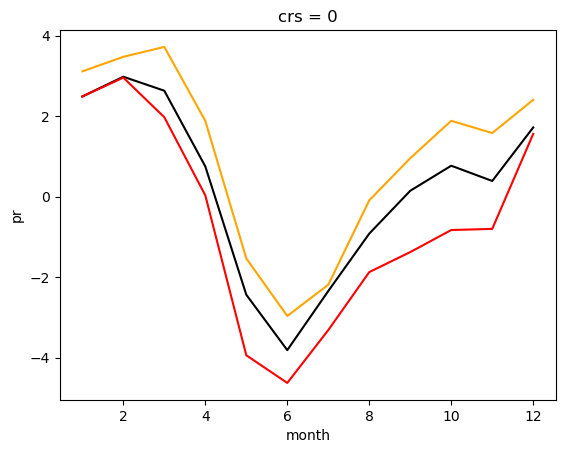

In [ ]:
difflo_pr_ctl.plot(color='black')
difflo_pr_4co2.plot(color='orange')
difflo_pr_p4k.plot(color='red')

_t2m_

In [ ]:
tas_ctl_mean_land = land(tas_ctl_mean)
tas_ctl_mean_ocean = ocean(tas_ctl_mean)
tas_4co2_mean_land = land(tas_4co2_mean)
tas_4co2_mean_ocean = ocean(tas_4co2_mean)
tas_p4k_mean_land = land(tas_p4k_mean)
tas_p4k_mean_ocean = ocean(tas_p4k_mean)

In [ ]:
tas_ngcb_mean_land = land(tas_ngcb_mean)
tas_ngcb_mean_ocean = ocean(tas_ngcb_mean)
tas_ngce_mean_land = land(tas_ngce_mean)
tas_ngce_mean_ocean = ocean(tas_ngce_mean)

In [ ]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
tas_ctl_mean_amz = tas_ctl_mean.isel(cell=is_amazon)
tas_4co2_mean_amz = tas_4co2_mean.isel(cell=is_amazon)
tas_p4k_mean_amz = tas_p4k_mean.isel(cell=is_amazon)

In [ ]:
tas_ctl_mean_land_interest = tas_ctl_mean_land.where(land_interest(tas_ctl_mean_land), drop=True)
tas_ctl_mean_ocean_interest = tas_ctl_mean_ocean.where(ocean_interest(tas_ctl_mean_ocean), drop=True)

In [ ]:
tas_4co2_mean_land_interest = tas_4co2_mean_land.where(land_interest(tas_4co2_mean_land), drop=True)
tas_4co2_mean_ocean_interest = tas_4co2_mean_ocean.where(ocean_interest(tas_4co2_mean_ocean), drop=True)

In [ ]:
tas_p4k_mean_land_interest = tas_p4k_mean_land.where(land_interest(tas_p4k_mean_land), drop=True)
tas_p4k_mean_ocean_interest = tas_p4k_mean_ocean.where(ocean_interest(tas_p4k_mean_ocean), drop=True)

In [ ]:
tas_ngcb_mean_land_interest = tas_ngcb_mean_land.where(land_interest(tas_ngcb_mean_land), drop=True)
tas_ngcb_mean_ocean_interest = tas_ngcb_mean_ocean.where(ocean_interest(tas_ngcb_mean_ocean), drop=True)

In [ ]:
tas_ngce_mean_land_interest = tas_ngce_mean_land.where(land_interest(tas_ngce_mean_land), drop=True)
tas_ngce_mean_ocean_interest = tas_ngce_mean_ocean.where(ocean_interest(tas_ngce_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_tas_ctl = tas_ctl_mean_amz.mean(dim='cell').compute() - tas_ctl_mean_ocean_interest.mean(dim='cell').compute()
difflo_tas_4co2 = tas_4co2_mean_amz.mean(dim='cell').compute() - tas_4co2_mean_ocean_interest.mean(dim='cell').compute()
difflo_tas_p4k = tas_p4k_mean_amz.mean(dim='cell').compute() - tas_p4k_mean_ocean_interest.mean(dim='cell').compute()

In [ ]:
difflo_tas_ngcb = tas_ngcb_mean_land_interest.mean(dim='cell').compute() - tas_ngcb_mean_ocean_interest.mean(dim='cell').compute()
difflo_tas_ngce = tas_ngce_mean_land_interest.mean(dim='cell').compute() - tas_ngce_mean_ocean_interest.mean(dim='cell').compute()

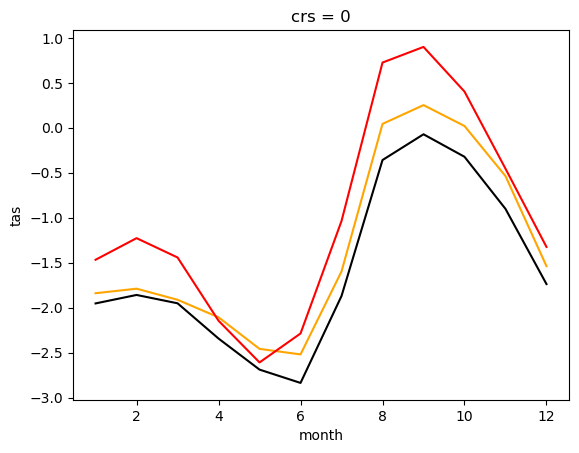

In [ ]:
difflo_tas_ctl.plot(color='black')
difflo_tas_4co2.plot(color='orange')
difflo_tas_p4k.plot(color='red')

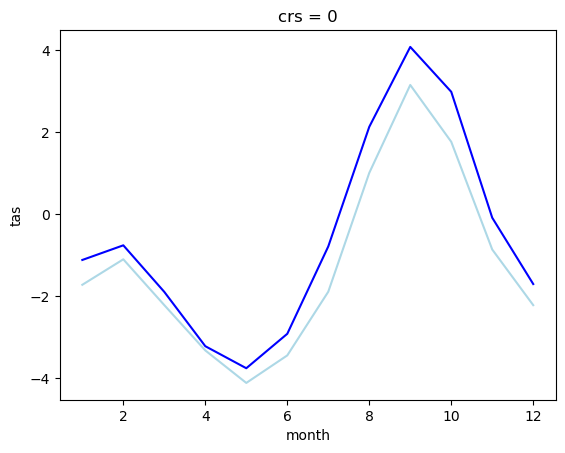

In [ ]:
difflo_tas_ngcb.plot(color='lightblue')
difflo_tas_ngce.plot(color='blue')

_prw_

In [ ]:
prw_ctl_land = land(prw_ctl)
prw_ctl_ocean = ocean(prw_ctl)
prw_4co2_land = land(prw_4co2)
prw_4co2_ocean = ocean(prw_4co2)
prw_p4k_land = land(prw_p4k)
prw_p4k_ocean = ocean(prw_p4k)

In [ ]:
prw_ngcb_mean_land = land(prw_ngcb_mean)
prw_ngcb_mean_ocean = ocean(prw_ngcb_mean)
prw_ngce_mean_land = land(prw_ngce_mean)
prw_ngce_mean_ocean = ocean(prw_ngce_mean)

In [ ]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
prw_ctl_amz = prw_ctl.isel(cell=is_amazon)
prw_4co2_amz = prw_4co2.isel(cell=is_amazon)
prw_p4k_amz = prw_p4k.isel(cell=is_amazon)

In [ ]:
prw_ngcb_amz = prw_ngcb_mean.isel(cell=is_amazon)
prw_ngce_amz = prw_ngce_mean.isel(cell=is_amazon)

In [ ]:
prw_ctl_land_interest = prw_ctl_land.where(land_interest(prw_ctl_land), drop=True)
prw_ctl_ocean_interest = prw_ctl_ocean.where(ocean_interest(prw_ctl_ocean), drop=True)

In [ ]:
prw_4co2_land_interest = prw_4co2_land.where(land_interest(prw_4co2_land), drop=True)
prw_4co2_ocean_interest = prw_4co2_ocean.where(ocean_interest(prw_4co2_ocean), drop=True)

In [ ]:
prw_p4k_land_interest = prw_p4k_land.where(land_interest(prw_p4k_land), drop=True)
prw_p4k_ocean_interest = prw_p4k_ocean.where(ocean_interest(prw_p4k_ocean), drop=True)

In [ ]:
prw_ngcb_mean_land_interest = prw_ngcb_mean_land.where(land_interest(prw_ngcb_mean_land), drop=True)
prw_ngcb_mean_ocean_interest = prw_ngcb_mean_ocean.where(ocean_interest(prw_ngcb_mean_ocean), drop=True)
prw_ngce_mean_land_interest = prw_ngce_mean_land.where(land_interest(prw_ngce_mean_land), drop=True)
prw_ngce_mean_ocean_interest = prw_ngce_mean_ocean.where(ocean_interest(prw_ngce_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_prw_ctl = prw_ctl_amz.mean(dim='cell').compute() - prw_ctl_ocean_interest.mean(dim='cell').compute()
difflo_prw_4co2 = prw_4co2_amz.mean(dim='cell').compute() - prw_4co2_ocean_interest.mean(dim='cell').compute()
difflo_prw_p4k = prw_p4k_amz.mean(dim='cell').compute() - prw_p4k_ocean_interest.mean(dim='cell').compute()

In [ ]:
difflo_prw_ngcb = prw_ngcb_amz.mean(dim='cell').compute() - prw_ngcb_mean_ocean_interest.mean(dim='cell').compute()
difflo_prw_ngce = prw_ngce_amz.mean(dim='cell').compute() - prw_ngce_mean_ocean_interest.mean(dim='cell').compute()

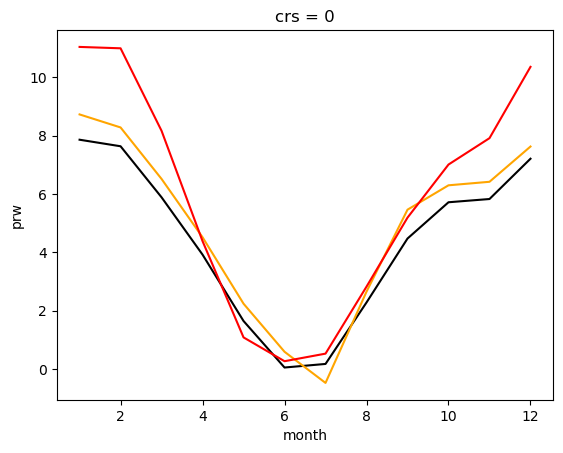

In [ ]:
difflo_prw_ctl.plot(color='black')
difflo_prw_4co2.plot(color='orange')
difflo_prw_p4k.plot(color='red')

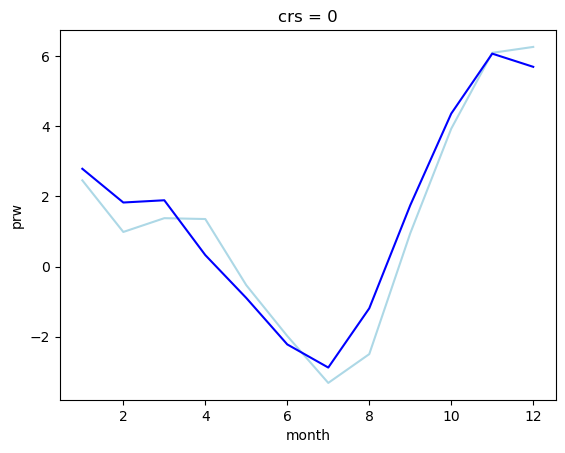

In [ ]:
difflo_prw_ngcb.plot(color='lightblue')
difflo_prw_ngce.plot(color='blue')

In [ ]:
print(difflo_prw_ctl.mean(dim='month').values, difflo_prw_4co2.mean(dim='month').values, difflo_prw_p4k.mean(dim='month').values)

4.391104 4.904544 5.812445


In [ ]:
print(difflo_prw_ngcb.mean(dim='month').values, difflo_prw_ngce.mean(dim='month').values)

1.258808 1.4614714


_LH_

In [ ]:
hfls_ctl_mean_land = land(hfls_ctl_mean)
hfls_ctl_mean_ocean = ocean(hfls_ctl_mean)
hfls_4co2_mean_land = land(hfls_4co2_mean)
hfls_4co2_mean_ocean = ocean(hfls_4co2_mean)
hfls_p4k_mean_land = land(hfls_p4k_mean)
hfls_p4k_mean_ocean = ocean(hfls_p4k_mean)

In [ ]:
hfls_ctl_mean_land_interest = hfls_ctl_mean_land.where(land_interest(hfls_ctl_mean_land), drop=True)
hfls_ctl_mean_ocean_interest = hfls_ctl_mean_ocean.where(ocean_interest(hfls_ctl_mean_ocean), drop=True)

In [ ]:
hfls_4co2_mean_land_interest = hfls_4co2_mean_land.where(land_interest(hfls_4co2_mean_land), drop=True)
hfls_4co2_mean_ocean_interest = hfls_4co2_mean_ocean.where(ocean_interest(hfls_4co2_mean_ocean), drop=True)

In [ ]:
hfls_p4k_mean_land_interest = hfls_p4k_mean_land.where(land_interest(hfls_p4k_mean_land), drop=True)
hfls_p4k_mean_ocean_interest = hfls_p4k_mean_ocean.where(ocean_interest(hfls_p4k_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_hfls_ctl = -hfls_ctl_mean_land_interest.mean(dim='cell').compute() + hfls_ctl_mean_ocean_interest.mean(dim='cell').compute()
difflo_hfls_4co2 = -hfls_4co2_mean_land_interest.mean(dim='cell').compute() + hfls_4co2_mean_ocean_interest.mean(dim='cell').compute()
difflo_hfls_p4k = -hfls_p4k_mean_land_interest.mean(dim='cell').compute() + hfls_p4k_mean_ocean_interest.mean(dim='cell').compute()

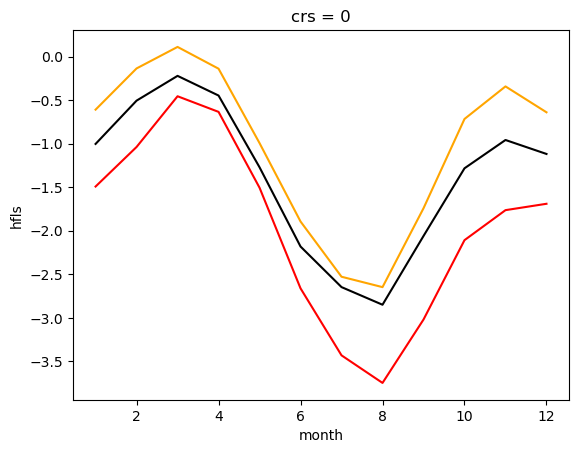

In [ ]:
difflo_hfls_ctl.plot(color='black')
difflo_hfls_4co2.plot(color='orange')
difflo_hfls_p4k.plot(color='red')

_SH_

In [ ]:
hfss_ctl_mean_land = land(hfss_ctl_mean)
hfss_ctl_mean_ocean = ocean(hfss_ctl_mean)
hfss_4co2_mean_land = land(hfss_4co2_mean)
hfss_4co2_mean_ocean = ocean(hfss_4co2_mean)
hfss_p4k_mean_land = land(hfss_p4k_mean)
hfss_p4k_mean_ocean = ocean(hfss_p4k_mean)

In [ ]:
hfss_ctl_mean_land_interest = hfss_ctl_mean_land.where(land_interest(hfss_ctl_mean_land), drop=True)
hfss_ctl_mean_ocean_interest = hfss_ctl_mean_ocean.where(ocean_interest(hfss_ctl_mean_ocean), drop=True)

In [ ]:
hfss_4co2_mean_land_interest = hfss_4co2_mean_land.where(land_interest(hfss_4co2_mean_land), drop=True)
hfss_4co2_mean_ocean_interest = hfss_4co2_mean_ocean.where(ocean_interest(hfss_4co2_mean_ocean), drop=True)

In [ ]:
hfss_p4k_mean_land_interest = hfss_p4k_mean_land.where(land_interest(hfss_p4k_mean_land), drop=True)
hfss_p4k_mean_ocean_interest = hfss_p4k_mean_ocean.where(ocean_interest(hfss_p4k_mean_ocean), drop=True)

_MSE_

In [ ]:
mse_ctl_mean_land = land(mse_ctl_mean)
mse_ctl_mean_ocean = ocean(mse_ctl_mean)
mse_4co2_mean_land = land(mse_4co2_mean)
mse_4co2_mean_ocean = ocean(mse_4co2_mean)
mse_p4k_mean_land = land(mse_p4k_mean)
mse_p4k_mean_ocean = ocean(mse_p4k_mean)

In [ ]:
mse_ngcb_mean_land = land_ngc(mse_ngcb_mean)
mse_ngcb_mean_ocean = ocean_ngc(mse_ngcb_mean)
mse_ngce_mean_land = land_ngc(mse_ngce_mean)
mse_ngce_mean_ocean = ocean_ngc(mse_ngce_mean)

In [ ]:
# amip
mse_ctl_mean_land_interest = mse_ctl_mean_land.where(land_interest(mse_ctl_mean_land), drop=True)
mse_ctl_mean_ocean_interest = mse_ctl_mean_ocean.where(ocean_interest(mse_ctl_mean_ocean), drop=True)

In [ ]:
mse_4co2_mean_land_interest = mse_4co2_mean_land.where(land_interest(mse_4co2_mean_land), drop=True)
mse_4co2_mean_ocean_interest = mse_4co2_mean_ocean.where(ocean_interest(mse_4co2_mean_ocean), drop=True)

In [ ]:
mse_p4k_mean_land_interest = mse_p4k_mean_land.where(land_interest(mse_p4k_mean_land), drop=True)
mse_p4k_mean_ocean_interest = mse_p4k_mean_ocean.where(ocean_interest(mse_p4k_mean_ocean), drop=True)

In [ ]:
# ngc
mse_ngcb_mean_land_interest = mse_ngcb_mean_land.where(land_interest(mse_ngcb_mean_land), drop=True)
mse_ngcb_mean_ocean_interest = mse_ngcb_mean_ocean.where(ocean_interest(mse_ngcb_mean_ocean), drop=True)

In [ ]:
mse_ngce_mean_land_interest = mse_ngce_mean_land.where(land_interest(mse_ngce_mean_land), drop=True)
mse_ngce_mean_ocean_interest = mse_ngce_mean_ocean.where(ocean_interest(mse_ngce_mean_ocean), drop=True)

_Difference between land and ocean_

_amip_

In [ ]:
difflo_mse_ctl = mse_ctl_mean_land_interest.mean(dim='cell').compute() - mse_ctl_mean_ocean_interest.mean(dim='cell').compute()
difflo_mse_4co2 = mse_4co2_mean_land_interest.mean(dim='cell').compute() - mse_4co2_mean_ocean_interest.mean(dim='cell').compute()
difflo_mse_p4k = mse_p4k_mean_land_interest.mean(dim='cell').compute() - mse_p4k_mean_ocean_interest.mean(dim='cell').compute()

In [ ]:
# J/lg
mse_ctl_land = mse_ctl_mean_land_interest.mean(dim='cell').compute()
mse_4co2_land = mse_4co2_mean_land_interest.mean(dim='cell').compute()
mse_p4k_land = mse_p4k_mean_land_interest.mean(dim='cell').compute()

In [ ]:
mse_ctl_ocean = mse_ctl_mean_ocean_interest.mean(dim='cell').compute()
mse_4co2_ocean = mse_4co2_mean_ocean_interest.mean(dim='cell').compute()
mse_p4k_ocean = mse_p4k_mean_ocean_interest.mean(dim='cell').compute()

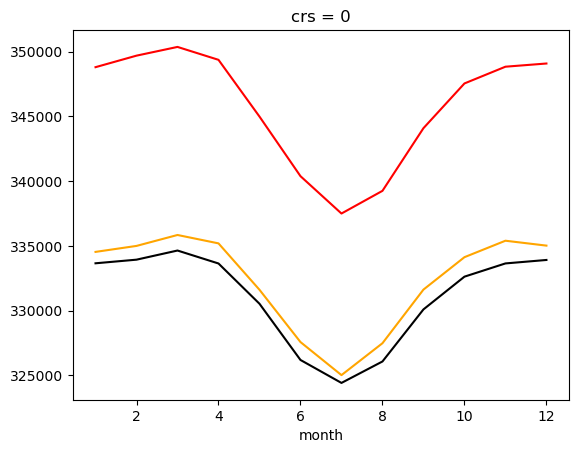

In [ ]:
mse_ctl_land.plot(color='black')
mse_4co2_land.plot(color='orange')
mse_p4k_land.plot(color='red')

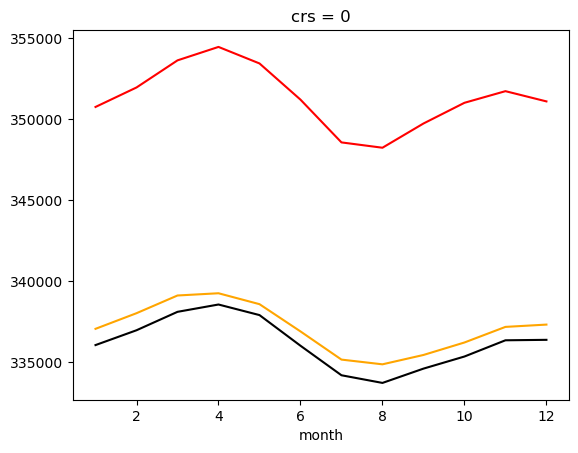

In [ ]:
mse_ctl_ocean.plot(color='black')
mse_4co2_ocean.plot(color='orange')
mse_p4k_ocean.plot(color='red')

In [ ]:
a = difflo_mse_4co2 - difflo_mse_ctl
b = difflo_mse_p4k - difflo_mse_ctl

(array([-1500., -1000.,  -500.,     0.,   500.,  1000.,  1500.]),
 [Text(0, -1500.0, '−1500'),
  Text(0, -1000.0, '−1000'),
  Text(0, -500.0, '−500'),
  Text(0, 0.0, '0'),
  Text(0, 500.0, '500'),
  Text(0, 1000.0, '1000'),
  Text(0, 1500.0, '1500')])

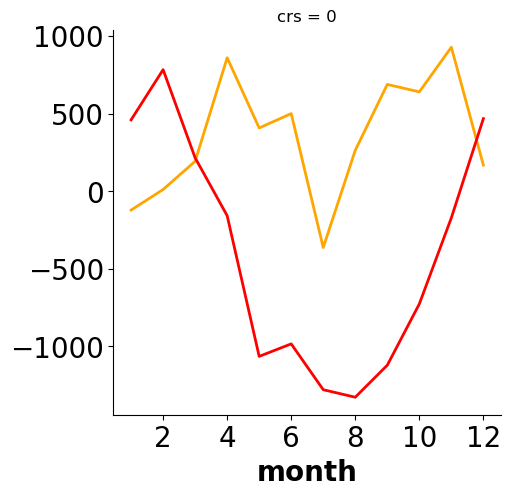

In [ ]:
# mse_land - mse_ocean, and changes of mse(land-ocean)
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlabel('Month', fontsize=20, weight='bold')
ax.set_ylabel('MSE [J/kg]', fontsize=20, weight='bold')
a.plot(color='orange', linewidth=2)
b.plot(color='red', linewidth=2)
ax.spines[['right', 'top']].set_visible(False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

In [ ]:
print(a.mean(dim='month').values)
print(b.mean(dim='month').values)

347.33072
-408.86197


_NGC_

In [ ]:
difflo_mse_ngcb = mse_ngcb_mean_land_interest.mean(dim='cell').compute() - mse_ngcb_mean_ocean_interest.mean(dim='cell').compute()
difflo_mse_ngce = mse_ngce_mean_land_interest.mean(dim='cell').compute() - mse_ngce_mean_ocean_interest.mean(dim='cell').compute()

In [ ]:
c = difflo_mse_ngce - difflo_mse_ngcb

(array([-1000.,  -800.,  -600.,  -400.,  -200.,     0.,   200.,   400.,
          600.,   800.]),
 [Text(0, -1000.0, '−1000'),
  Text(0, -800.0, '−800'),
  Text(0, -600.0, '−600'),
  Text(0, -400.0, '−400'),
  Text(0, -200.0, '−200'),
  Text(0, 0.0, '0'),
  Text(0, 200.0, '200'),
  Text(0, 400.0, '400'),
  Text(0, 600.0, '600'),
  Text(0, 800.0, '800')])

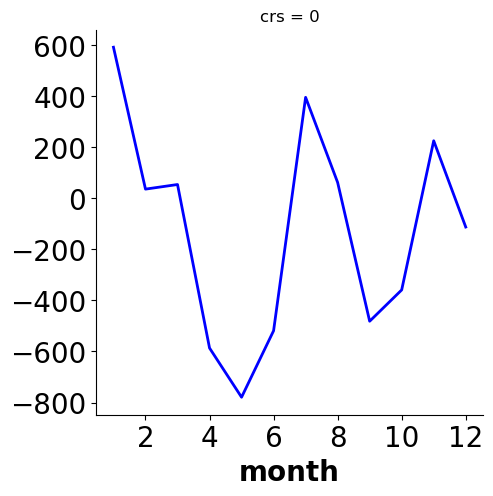

In [ ]:
# mse_land - mse_ocean, and changes of mse(land-ocean)
fig, ax = plt.subplots(figsize=(5,5))
ax.set_xlabel('Month', fontsize=20, weight='bold')
ax.set_ylabel('MSE [J/kg]', fontsize=20, weight='bold')
c.plot(color='blue', linewidth=2)
ax.spines[['right', 'top']].set_visible(False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

In [ ]:
print(c.mean(dim='month').values)

-122.57552


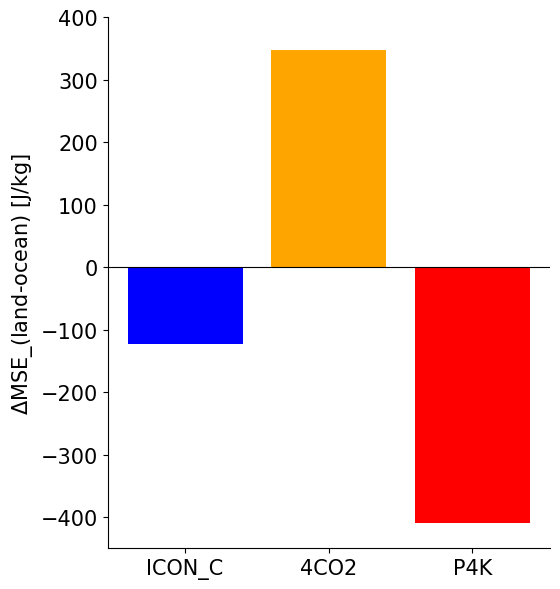

In [ ]:
# Set the positions and width for the bars
import pandas as pd
df = pd.DataFrame([[-122.58, 347.33, -408.86]], columns=['ICON_C','4CO2','P4K'], index=['MSE_LO'])

x = np.arange(len(df.columns))
width = 0.25

fig, ax = plt.subplots(1,1, figsize=(6, 6), sharey=False)

colors = ['blue', 'orange', 'red']
labels = df.columns
ylims = [(-450, 400)]

# Plotting each subplot

ax.bar(labels, df.iloc[0], color=colors)
ax.spines[['right', 'top']].set_visible(False)
ax.tick_params(axis='y', labelsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.axhline(0, color='black', linewidth=0.8)
    
ax.set_ylim(ylims[0])
ax.set_ylabel(r'$\Delta$MSE_(land-ocean) [J/kg]', fontsize=15)
        #ax.set_ylim(-0.5, 10)
        #ax.set_ylabel(r'$\Delta$Net surface radiation [mm/day]',fontsize=30, labelpad = 10,family='Arial')        #ax.set_ylim(-0.1, 0.1)
# Adding vertical separators
#for i in range(1, 3):
#    fig.add_artist(plt.Line2D([i / 3, i / 3], [0.1, 0.9], color='black', linewidth=2, transform=fig.transFigure))

# Legend
#fig.legend(labels, loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

_Moisture convergence_

In [ ]:
# moisture convergence over land
convg_ctl_mean_land = pr_ctl_mean_land_interest + hfls_ctl_mean_land_interest
convg_4co2_mean_land = pr_4co2_mean_land_interest + hfls_4co2_mean_land_interest
convg_p4k_mean_land = pr_p4k_mean_land_interest + hfls_p4k_mean_land_interest

_moist static energy_

In [ ]:
mse_ctl_mean_land = land(mse_ctl_mean)
mse_4co2_mean_land = land(mse_4co2_mean)
mse_p4k_mean_land = land(mse_p4k_mean)

In [ ]:
mse_ctl_mean_land_interest = mse_ctl_mean_land.where(land_interest(mse_ctl_mean_land), drop=True)
mse_4co2_mean_land_interest = mse_4co2_mean_land.where(ocean_interest(mse_4co2_mean_land), drop=True)
mse_p4k_mean_land_interest = mse_p4k_mean_land.where(land_interest(mse_p4k_mean_land), drop=True)

#### Correlation graph

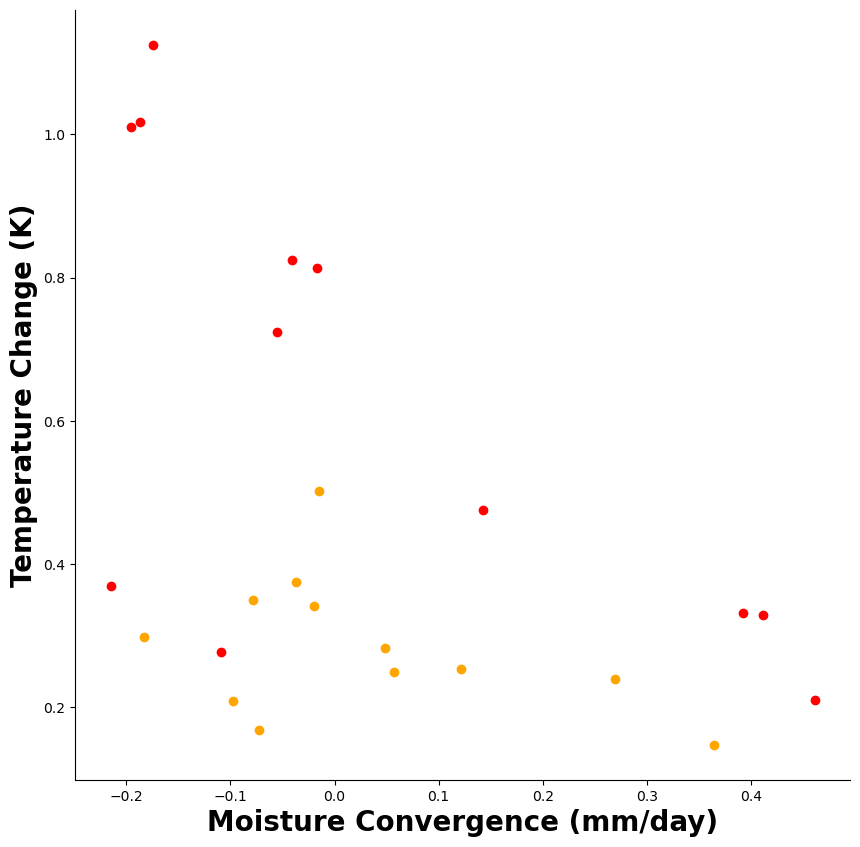

In [ ]:
x_co2 = convg_4co2_mean_land.mean(dim='cell').compute() - convg_ctl_mean_land.mean(dim='cell').compute()
y_co2 = difflo_tas_4co2 - difflo_tas_ctl
x_sst = convg_p4k_mean_land.mean(dim='cell').compute() - convg_ctl_mean_land.mean(dim='cell').compute()
y_sst = difflo_tas_p4k - difflo_tas_ctl

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('Moisture Convergence (mm/day)', fontsize=20, weight='bold')
ax.set_ylabel('Temperature Change (K)', fontsize=20, weight='bold')
plt.scatter(x_co2, y_co2, color='orange', label='4CO2')
plt.scatter(x_sst, y_sst, color='red', label='P4K')
ax.spines[['right', 'top']].set_visible(False)

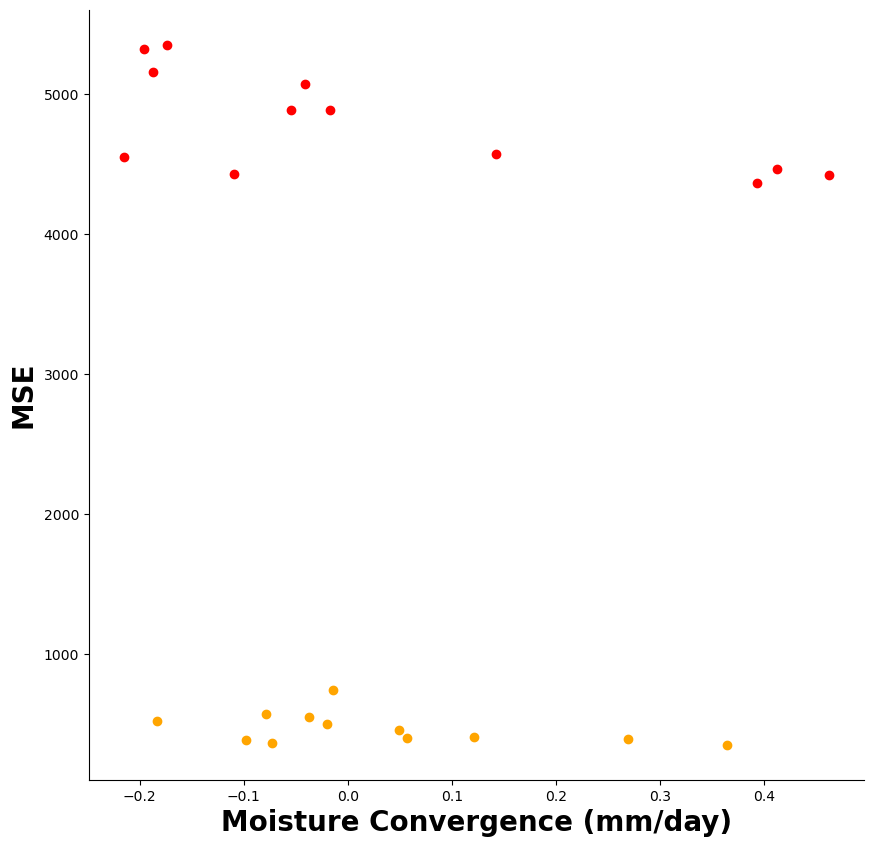

In [ ]:
x_co2 = convg_4co2_mean_land.mean(dim='cell').compute() - convg_ctl_mean_land.mean(dim='cell').compute()
y_co2 = mse_4co2_mean_land_interest.mean(dim='cell').compute() - mse_ctl_mean_land_interest.mean(dim='cell').compute()
x_sst = convg_p4k_mean_land.mean(dim='cell').compute() - convg_ctl_mean_land.mean(dim='cell').compute()
y_sst = mse_p4k_mean_land_interest.mean(dim='cell').compute() - mse_ctl_mean_land_interest.mean(dim='cell').compute()

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('Moisture Convergence (mm/day)', fontsize=20, weight='bold')
ax.set_ylabel('MSE', fontsize=20, weight='bold')
plt.scatter(x_co2, y_co2, color='orange', label='4CO2')
plt.scatter(x_sst, y_sst, color='red', label='P4K')
ax.spines[['right', 'top']].set_visible(False)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

## NGC4

_PR_

In [ ]:
pr_ngcb_mean_land = land(pr_ngcb_mean)
pr_ngcb_mean_ocean = ocean(pr_ngcb_mean)
pr_ngce_mean_land = land(pr_ngce_mean)
pr_ngce_mean_ocean = ocean(pr_ngce_mean)

In [ ]:
pr_ngcb_mean_land_interest = pr_ngcb_mean_land.where(land_interest(pr_ngcb_mean_land), drop=True)
pr_ngcb_mean_ocean_interest = pr_ngcb_mean_ocean.where(ocean_interest(pr_ngcb_mean_ocean), drop=True)

In [ ]:
pr_ngce_mean_land_interest = pr_ngce_mean_land.where(land_interest(pr_ngce_mean_land), drop=True)
pr_ngce_mean_ocean_interest = pr_ngce_mean_ocean.where(ocean_interest(pr_ngce_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_pr_ngcb = pr_ngcb_mean_land_interest.mean(dim='cell').compute() - pr_ngcb_mean_ocean_interest.mean(dim='cell').compute()
difflo_pr_ngce = pr_ngce_mean_land_interest.mean(dim='cell').compute() - pr_ngce_mean_ocean_interest.mean(dim='cell').compute()

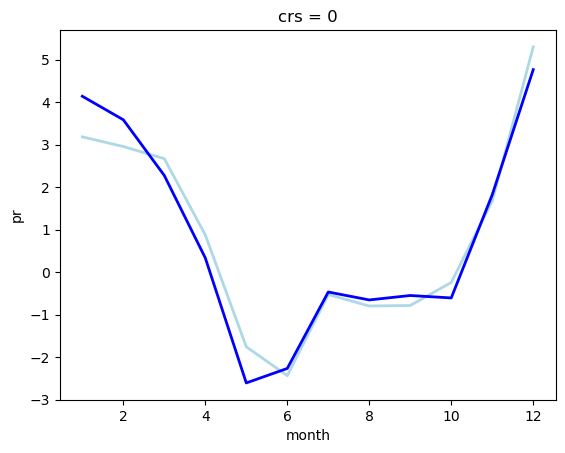

In [ ]:
difflo_pr_ngcb.plot(color='lightblue',linewidth=2)
difflo_pr_ngce.plot(color='blue',linewidth=2)

_HFLS_

In [ ]:
hfls_ngcb_mean_land = land(hfls_ngcb_mean)
hfls_ngcb_mean_ocean = ocean(hfls_ngcb_mean)
hfls_ngce_mean_land = land(hfls_ngce_mean)
hfls_ngce_mean_ocean = ocean(hfls_ngce_mean)

In [ ]:
hfls_ngcb_mean_land_interest = hfls_ngcb_mean_land.where(land_interest(hfls_ngcb_mean_land), drop=True)
hfls_ngcb_mean_ocean_interest = hfls_ngcb_mean_ocean.where(ocean_interest(hfls_ngcb_mean_ocean), drop=True)

In [ ]:
hfls_ngce_mean_land_interest = hfls_ngce_mean_land.where(land_interest(hfls_ngce_mean_land), drop=True)
hfls_ngce_mean_ocean_interest = hfls_ngce_mean_ocean.where(ocean_interest(hfls_ngce_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_hfls_ngcb = -hfls_ngcb_mean_land_interest.mean(dim='cell').compute() + hfls_ngcb_mean_ocean_interest.mean(dim='cell').compute()
difflo_hfls_ngce = -hfls_ngce_mean_land_interest.mean(dim='cell').compute() + hfls_ngce_mean_ocean_interest.mean(dim='cell').compute()

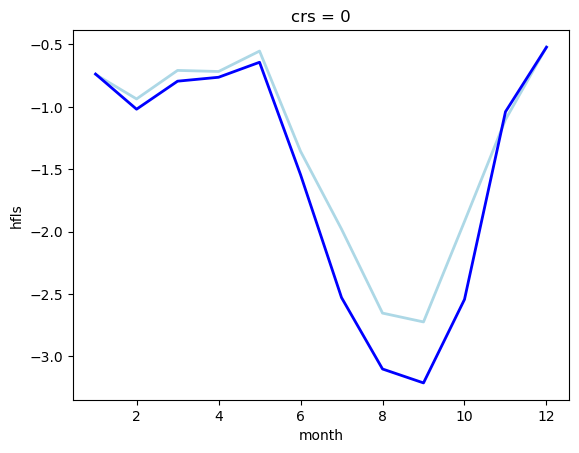

In [ ]:
difflo_hfls_ngcb.plot(color='lightblue',linewidth=2)
difflo_hfls_ngce.plot(color='blue',linewidth=2)

_HFSS_

In [ ]:
hfss_ngcb_mean_land = land(hfss_ngcb_mean)
hfss_ngcb_mean_ocean = ocean(hfss_ngcb_mean)
hfss_ngce_mean_land = land(hfss_ngce_mean)
hfss_ngce_mean_ocean = ocean(hfss_ngce_mean)

In [ ]:
hfss_ngcb_mean_land_interest = hfss_ngcb_mean_land.where(land_interest(hfss_ngcb_mean_land), drop=True)
hfss_ngcb_mean_ocean_interest = hfss_ngcb_mean_ocean.where(ocean_interest(hfss_ngcb_mean_ocean), drop=True)

In [ ]:
hfss_ngce_mean_land_interest = hfss_ngce_mean_land.where(land_interest(hfss_ngce_mean_land), drop=True)
hfss_ngce_mean_ocean_interest = hfss_ngce_mean_ocean.where(ocean_interest(hfss_ngce_mean_ocean), drop=True)

_Difference between land and ocean_

In [ ]:
difflo_hfss_ngcb = -hfss_ngcb_mean_land_interest.mean(dim='cell').compute() + hfss_ngcb_mean_ocean_interest.mean(dim='cell').compute()
difflo_hfss_ngce = -hfss_ngce_mean_land_interest.mean(dim='cell').compute() + hfss_ngce_mean_ocean_interest.mean(dim='cell').compute()

In [ ]:
difflo_fluxes_ngcb = difflo_hfls_ngcb + difflo_hfss_ngcb
difflo_fluxes_ngce = difflo_hfls_ngce + difflo_hfss_ngce

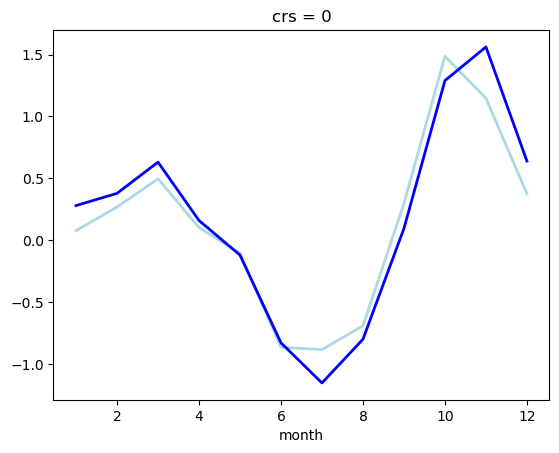

In [ ]:
difflo_fluxes_ngcb.plot(color='lightblue',linewidth=2)
difflo_fluxes_ngce.plot(color='blue',linewidth=2)

## correlation graph

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 467 times more chunks
  return self.array[key]
/tmp/ipykernel_2945085/3064748190.py:41: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)


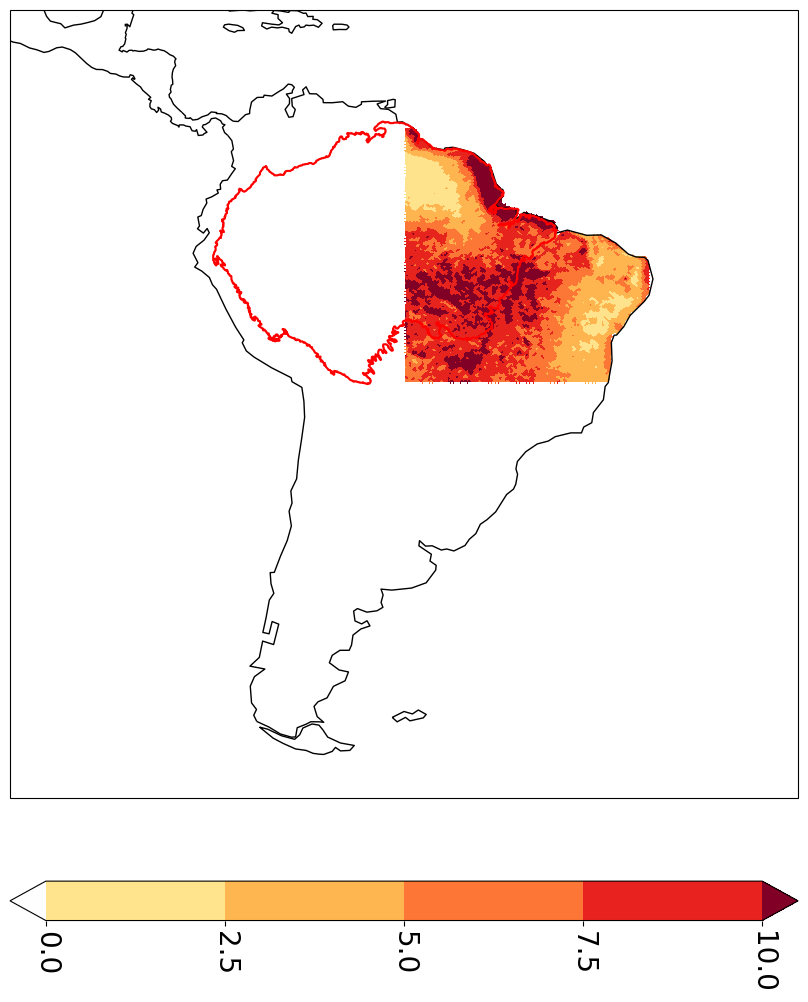

In [ ]:
plot_map_healpix(pr_ctl_mean_land_interest.isel(month=0), ax=None, title=None, colorbar=True, cmap=YlOrRd_new, nest=True, vmin=0, vmax=10, space=5, extend='both', latmin=-60, latmax=20, lonmin=-100, lonmax=-20)

/home/m/m300948/.conda/envs/precippuzzle/lib/python3.12/site-packages/xarray/core/indexing.py:1593: PerformanceWarning: Slicing with an out-of-order index is generating 398 times more chunks
  return self.array[key]
/tmp/ipykernel_2945085/3064748190.py:41: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  _ = fig.subplots_adjust(left=0.01, right=0.98, hspace=0, wspace=0, top=0.9, bottom=0.25)


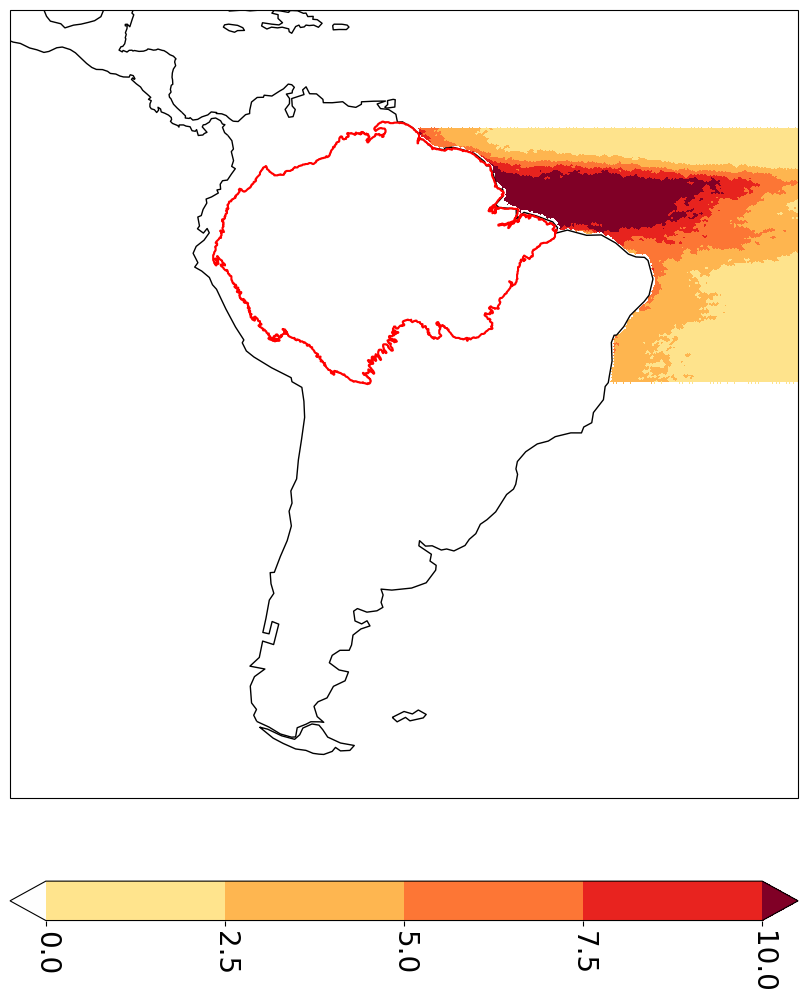

In [ ]:
plot_map_healpix(pr_ctl_mean_ocean_interest.isel(month=0), ax=None, title=None, colorbar=True, cmap=YlOrRd_new, nest=True, vmin=0, vmax=10, space=5, extend='both', latmin=-60, latmax=20, lonmin=-100, lonmax=-20)

# 1. For the whole level

## Temperature

_amip_

In [15]:
ta_ctl_mean = dx_ctl.ta.mean('time') 
ta_4co2_mean = dx_4co2.ta.mean('time')
ta_p4k_mean = dx_p4k.ta.mean('time')

_ngc_

In [13]:
ta_ngcb_mean = dx_ngc_start.ta
ta_ngce_mean = dx_ngc_end.ta

## Moist static energy

_amip_

In [16]:
hus_ctl_mean = dx_ctl.hus.mean('time') 
hus_4co2_mean = dx_4co2.hus.mean('time') 
hus_p4k_mean = dx_p4k.hus.mean('time')

_ngc_

In [14]:
hus_ngcb_mean = dx_ngc_start.hus
hus_ngce_mean = dx_ngc_end.hus

### Amazon masking

In [32]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
ta_ctl_mean_amz = ta_ctl_mean.isel(cell=is_amazon)
ta_4co2_mean_amz = ta_4co2_mean.isel(cell=is_amazon)
ta_p4k_mean_amz = ta_p4k_mean.isel(cell=is_amazon)

In [15]:
is_amazon = get_amazon_index(nside=egh.get_nside(data_ctl))
ta_ngcb_mean_amz = ta_ngcb_mean.isel(cell=is_amazon)
ta_ngce_mean_amz = ta_ngce_mean.isel(cell=is_amazon)

In [16]:
hus_ngcb_mean_amz = hus_ngcb_mean.isel(cell=is_amazon)
hus_ngce_mean_amz = hus_ngce_mean.isel(cell=is_amazon)

In [27]:
dx_ngc_start.pfull.isel(time=0, cell=0).values


array([1.86630070e+00, 2.90454674e+00, 4.35426283e+00, 6.40212917e+00,
       9.22020435e+00, 1.29772730e+01, 1.79125004e+01, 2.43552036e+01,
       3.25347137e+01, 4.27986145e+01, 5.57178078e+01, 7.19533386e+01,
       9.21582565e+01, 1.16924507e+02, 1.47304703e+02, 1.84411835e+02,
       2.29387299e+02, 2.84534149e+02, 3.52771545e+02, 4.36798065e+02,
       5.38939331e+02, 6.61717712e+02, 8.07453003e+02, 9.80377747e+02,
       1.18538770e+03, 1.42479321e+03, 1.70147717e+03, 2.02301465e+03,
       2.39571167e+03, 2.82100024e+03, 3.29760474e+03, 3.82088428e+03,
       4.39079248e+03, 5.00729688e+03, 5.67376758e+03, 6.40081494e+03,
       7.18948193e+03, 8.04016406e+03, 8.94340039e+03, 9.87679492e+03,
       1.08295273e+04, 1.17959961e+04, 1.27782412e+04, 1.37816162e+04,
       1.48146475e+04, 1.58796006e+04, 1.69861816e+04, 1.81501445e+04,
       1.93727734e+04, 2.06559473e+04, 2.20018574e+04, 2.34129648e+04,
       2.48914824e+04, 2.64392207e+04, 2.80582852e+04, 2.97498203e+04,
      

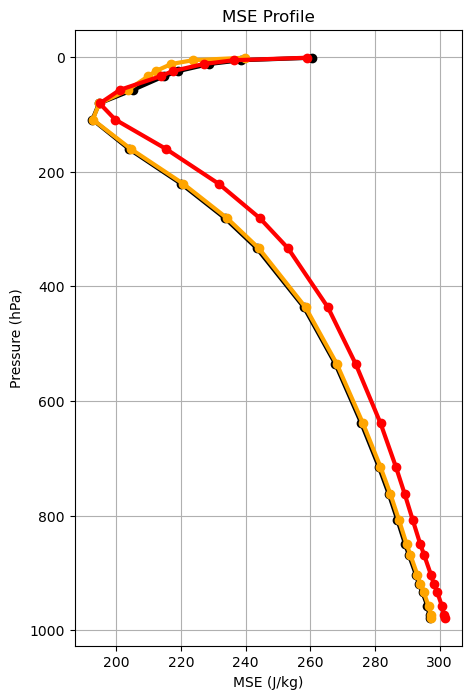

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pressure levels in hPa (from surface to upper atmosphere)
plev = np.array([  1.2115074,   5.57278  ,  12.158848 ,  24.475706 ,  33.46909  ,
        57.397804 ,  81.01849  , 109.088196 , 160.38899  , 221.31165  ,
       281.34683  , 333.71637  , 436.8011   , 535.1842   , 639.118    ,
       714.5451   , 762.3681   , 807.4611   , 849.1616   , 868.5213   ,
       903.796    , 919.5134   , 933.8083   , 957.6135   , 973.7673   ,
       978.05365  ])  # Example pressure levels

# Plot vertical profile
plt.figure(figsize=(5, 8))
plt.plot(ta_ctl_mean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='black')
plt.plot(ta_4co2_mean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='orange')
plt.plot(ta_p4k_mean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='red')

# Reverse y-axis so that surface is at the bottom and upper atmosphere is at the top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("MSE (J/kg)")
plt.ylabel("Pressure (hPa)")
plt.title("MSE Profile")
plt.grid()
plt.ylim(1000, 200)
# Show plot
plt.show()


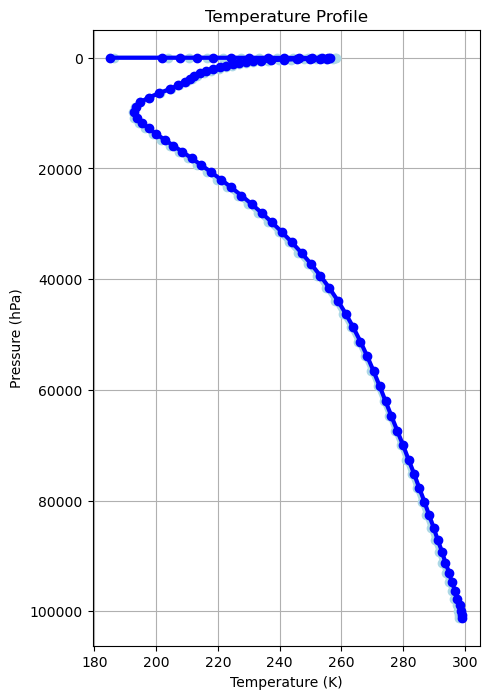

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pressure levels in hPa (from surface to upper atmosphere)
plev = np.array([1.86630070e+00, 2.90454674e+00, 4.35426283e+00, 6.40212917e+00,
       9.22020435e+00, 1.29772730e+01, 1.79125004e+01, 2.43552036e+01,
       3.25347137e+01, 4.27986145e+01, 5.57178078e+01, 7.19533386e+01,
       9.21582565e+01, 1.16924507e+02, 1.47304703e+02, 1.84411835e+02,
       2.29387299e+02, 2.84534149e+02, 3.52771545e+02, 4.36798065e+02,
       5.38939331e+02, 6.61717712e+02, 8.07453003e+02, 9.80377747e+02,
       1.18538770e+03, 1.42479321e+03, 1.70147717e+03, 2.02301465e+03,
       2.39571167e+03, 2.82100024e+03, 3.29760474e+03, 3.82088428e+03,
       4.39079248e+03, 5.00729688e+03, 5.67376758e+03, 6.40081494e+03,
       7.18948193e+03, 8.04016406e+03, 8.94340039e+03, 9.87679492e+03,
       1.08295273e+04, 1.17959961e+04, 1.27782412e+04, 1.37816162e+04,
       1.48146475e+04, 1.58796006e+04, 1.69861816e+04, 1.81501445e+04,
       1.93727734e+04, 2.06559473e+04, 2.20018574e+04, 2.34129648e+04,
       2.48914824e+04, 2.64392207e+04, 2.80582852e+04, 2.97498203e+04,
       3.15160332e+04, 3.33600508e+04, 3.52843828e+04, 3.72925195e+04,
       3.93880430e+04, 4.15747656e+04, 4.38541367e+04, 4.62262422e+04,
       4.86954414e+04, 5.12675430e+04, 5.39191211e+04, 5.66090703e+04,
       5.93151914e+04, 6.20207773e+04, 6.47133242e+04, 6.73871172e+04,
       7.00365469e+04, 7.26558438e+04, 7.52301172e+04, 7.77501484e+04,
       8.02072891e+04, 8.25918750e+04, 8.48955156e+04, 8.71058125e+04,
       8.92114375e+04, 9.11984844e+04, 9.30557578e+04, 9.47721797e+04,
       9.63361797e+04, 9.77308906e+04, 9.89377266e+04, 9.99349922e+04,
       1.00693164e+05, 1.01152977e+05])  # Example pressure levels

# Plot vertical profile
plt.figure(figsize=(5, 8))
plt.plot(ta_ngc_tmean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='lightblue')
plt.plot(ta_ngce_tmean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='blue')

# Reverse y-axis so that surface is at the bottom and upper atmosphere is at the top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("Temperature (K)")
plt.ylabel("Pressure (hPa)")
plt.title("Temperature Profile")
plt.grid()
#plt.ylim(1000, 200)
# Show plot
plt.show()


In [33]:
hus_ctl_mean_amz = hus_ctl_mean.isel(cell=is_amazon)
hus_4co2_mean_amz = hus_4co2_mean.isel(cell=is_amazon)
hus_p4k_mean_amz = hus_p4k_mean.isel(cell=is_amazon)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pressure levels in hPa (from surface to upper atmosphere)
plev = np.array([  1.2115074,   5.57278  ,  12.158848 ,  24.475706 ,  33.46909  ,
        57.397804 ,  81.01849  , 109.088196 , 160.38899  , 221.31165  ,
       281.34683  , 333.71637  , 436.8011   , 535.1842   , 639.118    ,
       714.5451   , 762.3681   , 807.4611   , 849.1616   , 868.5213   ,
       903.796    , 919.5134   , 933.8083   , 957.6135   , 973.7673   ,
       978.05365  ])  # Example pressure levels

# Plot vertical profile
plt.figure(figsize=(5, 8))
plt.plot(hus_ctl_mean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='black')
plt.plot(hus_4co2_mean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='orange')
plt.plot(hus_p4k_mean_amz.mean(dim='cell'), plev, lw=3, marker='o', linestyle='-', color='red')

# Reverse y-axis so that surface is at the bottom and upper atmosphere is at the top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("MSE (J/kg)")
plt.ylabel("Pressure (hPa)")
plt.title("MSE Profile")
plt.grid()

# Show plot
plt.show()


In [34]:
zg_amz = dx_ctl.zg.isel(cell=is_amazon)

In [ ]:
zg_amz = dx_ctl.zg.isel(cell=is_amazon)

In [20]:
ngc_zg_amz = dx_ngc_start.zg.isel(cell=is_amazon)

In [22]:
import xarray as xr

# Constants
cp = 1005        # J/kg/K
Lv = 2.5e6       # J/kg
g = 9.81         # m/s^2
z = ngc_zg_amz        # meters (zg_amz or ngc_zg_amz)

# Assuming you have xarray DataArrays: T2m (in K), q2m (in kg/kg)
# Example: T2m = ds['t2m'], q2m = ds['q2m']

def compute_mse(T, q):
    mse = cp * T + Lv * q + g * z
    return mse


In [25]:
ta_ngcb_tmean_amz = ta_ngcb_mean_amz.mean(dim='time')
ta_ngce_tmean_amz = ta_ngce_mean_amz.mean(dim='time')

hus_ngcb_tmean_amz = hus_ngcb_mean_amz.mean(dim='time')
hus_ngce_tmean_amz = hus_ngce_mean_amz.mean(dim='time')

In [35]:
mse_ctl_amz_mean = compute_mse(ta_ctl_mean_amz, hus_ctl_mean_amz)
mse_4co2_amz_mean = compute_mse(ta_4co2_mean_amz, hus_4co2_mean_amz)
mse_p4k_amz_mean = compute_mse(ta_p4k_mean_amz, hus_p4k_mean_amz)

In [29]:
ta_ngcb_tmean_amz.sel(level_full=ta_ngcb_tmean_amz.level_full[::3])

<xarray.DataArray 'ta' (level_full: 30, cell: 10611)> Size: 1MB
array([[185.98595, 185.99417, 186.00128, ..., 186.31445, 186.31564,
        186.317  ],
       [216.42229, 216.43047, 216.43527, ..., 216.0231 , 216.02188,
        216.02211],
       [232.7982 , 232.80185, 232.80244, ..., 233.5209 , 233.51942,
        233.51964],
       ...,
       [276.98682, 276.7636 , 277.17474, ..., 291.65125, 291.63535,
        291.6299 ],
       [278.0077 , 277.78122, 278.27484, ..., 294.4309 , 294.4008 ,
        294.32275],
       [278.59695, 278.43445, 278.9708 , ..., 296.8583 , 296.8564 ,
        296.86484]], shape=(30, 10611), dtype=float32)
Coordinates:
  * level_full  (level_full) int32 120B 1 4 7 10 13 16 19 ... 73 76 79 82 85 88
    crs         int64 8B 0
  * cell        (cell) int64 85kB 475205 475207 475213 ... 786402 786408 786410
    lat         (cell) float64 85kB -17.58 -17.43 -17.27 ... -1.343 -1.194
    lon         (cell) float64 85kB 294.4 294.3 294.1 ... 314.1 313.9 313.8

In [30]:
mse_ngcb_amz_tmean = compute_mse(ta_ngcb_tmean_amz.sel(level_full=ta_ngcb_tmean_amz.level_full[::3]), hus_ngcb_tmean_amz.sel(level_full=hus_ngcb_tmean_amz.level_full[::3]))
mse_ngce_amz_tmean = compute_mse(ta_ngce_tmean_amz.sel(level_full=ta_ngce_tmean_amz.level_full[::3]), hus_ngce_tmean_amz.sel(level_full=hus_ngce_tmean_amz.level_full[::3]))

_amips_

In [41]:
mse_ctl_amz_mean.mean(dim='cell').values

array([713105.  , 580899.2 , 518725.53, 464126.44, 440134.28, 397849.34,
       367578.7 , 349027.16, 338603.7 , 335375.16, 333650.34, 332330.06,
       329442.3 , 327035.2 , 325653.16, 325770.44, 326839.47, 329008.66,
       331948.84, 333327.78, 335784.97, 336732.56, 337113.  , 337690.84,
       338154.88, 338536.72], dtype=float32)

In [42]:
mse_4co2_amz_mean.mean(dim='cell').values

array([692152.3 , 565989.94, 506970.75, 457095.12, 435266.3 , 396312.  ,
       367629.25, 349158.44, 339164.78, 336039.25, 334366.03, 333035.28,
       330086.1 , 327649.9 , 326264.6 , 326461.12, 327639.88, 329945.03,
       333027.4 , 334457.22, 337012.75, 337999.3 , 338395.1 , 338987.56,
       339476.88, 339886.9 ], dtype=float32)

In [43]:
mse_p4k_amz_mean.mean(dim='cell').values

array([711538.2 , 578771.5 , 517043.28, 462413.2 , 439095.62, 393777.9 ,
       367789.47, 356125.5 , 350188.38, 347322.94, 345122.  , 343096.22,
       339313.38, 337047.16, 336293.34, 337401.4 , 339423.34, 342303.47,
       345615.62, 347116.6 , 349933.8 , 351086.5 , 351555.75, 352342.  ,
       353096.84, 353661.4 ], dtype=float32)

In [47]:
a = np.array([713105.  , 580899.2 , 518725.53, 464126.44, 440134.28, 397849.34,
       367578.7 , 349027.16, 338603.7 , 335375.16, 333650.34, 332330.06,
       329442.3 , 327035.2 , 325653.16, 325770.44, 326839.47, 329008.66,
       331948.84, 333327.78, 335784.97, 336732.56, 337113.  , 337690.84,
       338154.88, 338536.72])* 0.00001
b = np.array([692152.3 , 565989.94, 506970.75, 457095.12, 435266.3 , 396312.  ,
       367629.25, 349158.44, 339164.78, 336039.25, 334366.03, 333035.28,
       330086.1 , 327649.9 , 326264.6 , 326461.12, 327639.88, 329945.03,
       333027.4 , 334457.22, 337012.75, 337999.3 , 338395.1 , 338987.56,
       339476.88, 339886.9 ])* 0.00001
c = np.array([711538.2 , 578771.5 , 517043.28, 462413.2 , 439095.62, 393777.9 ,
       367789.47, 356125.5 , 350188.38, 347322.94, 345122.  , 343096.22,
       339313.38, 337047.16, 336293.34, 337401.4 , 339423.34, 342303.47,
       345615.62, 347116.6 , 349933.8 , 351086.5 , 351555.75, 352342.  ,
       353096.84, 353661.4 ])* 0.00001

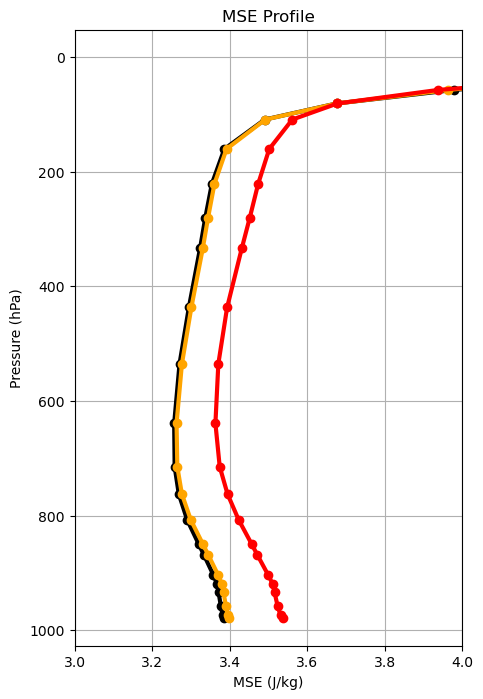

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pressure levels in hPa (from surface to upper atmosphere)
plev = np.array([  1.2115074,   5.57278  ,  12.158848 ,  24.475706 ,  33.46909  ,
        57.397804 ,  81.01849  , 109.088196 , 160.38899  , 221.31165  ,
       281.34683  , 333.71637  , 436.8011   , 535.1842   , 639.118    ,
       714.5451   , 762.3681   , 807.4611   , 849.1616   , 868.5213   ,
       903.796    , 919.5134   , 933.8083   , 957.6135   , 973.7673   ,
       978.05365  ])  # Example pressure levels

# Plot vertical profile
plt.figure(figsize=(5, 8))
plt.plot(a, plev, lw=3, marker='o', linestyle='-', color='black')
plt.plot(b, plev, lw=3, marker='o', linestyle='-', color='orange')
plt.plot(c, plev, lw=3, marker='o', linestyle='-', color='red')

# Reverse y-axis so that surface is at the bottom and upper atmosphere is at the top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("MSE (J/kg)")
plt.ylabel("Pressure (hPa)")
plt.title("MSE Profile")
plt.grid()
plt.xlim(3, 4)
#plt.yscale('log')
# Show plot
plt.show()


_NGC_

In [32]:
mse_ngcb_amz_tmean.mean(dim='cell').values

array([910623.9 , 869363.4 , 820388.94, 775769.44, 728186.  , 673570.56,
       615076.  , 562130.25, 516719.38, 475848.06, 438717.28, 407654.38,
       376785.03, 353937.47, 343523.34, 339035.44, 336325.53, 334445.88,
       332968.47, 331542.5 , 329857.25, 327764.5 , 325746.5 , 324457.47,
       324616.7 , 326381.6 , 329171.5 , 332421.28, 334121.53, 334839.9 ],
      dtype=float32)

In [33]:
mse_ngce_amz_tmean.mean(dim='cell').values

array([909287.2 , 866157.5 , 817240.8 , 772917.06, 725879.06, 671551.9 ,
       612695.5 , 559820.06, 514709.1 , 473991.75, 437662.47, 407173.28,
       376696.9 , 354507.8 , 344523.03, 340207.38, 337554.9 , 335697.47,
       334194.9 , 332692.25, 330895.12, 328695.9 , 326599.47, 325379.2 ,
       325825.88, 327803.3 , 330598.1 , 333699.8 , 335340.  , 336061.72],
      dtype=float32)

In [34]:
a = np.array([910623.9 , 869363.4 , 820388.94, 775769.44, 728186.  , 673570.56,
       615076.  , 562130.25, 516719.38, 475848.06, 438717.28, 407654.38,
       376785.03, 353937.47, 343523.34, 339035.44, 336325.53, 334445.88,
       332968.47, 331542.5 , 329857.25, 327764.5 , 325746.5 , 324457.47,
       324616.7 , 326381.6 , 329171.5 , 332421.28, 334121.53, 334839.9 ])* 0.00001
b = np.array([909287.2 , 866157.5 , 817240.8 , 772917.06, 725879.06, 671551.9 ,
       612695.5 , 559820.06, 514709.1 , 473991.75, 437662.47, 407173.28,
       376696.9 , 354507.8 , 344523.03, 340207.38, 337554.9 , 335697.47,
       334194.9 , 332692.25, 330895.12, 328695.9 , 326599.47, 325379.2 ,
       325825.88, 327803.3 , 330598.1 , 333699.8 , 335340.  , 336061.72])* 0.00001

In [45]:
plev_ngc = np.array([1.86630070e+00, 2.90454674e+00, 4.35426283e+00, 6.40212917e+00,
       9.22020435e+00, 1.29772730e+01, 1.79125004e+01, 2.43552036e+01,
       3.25347137e+01, 4.27986145e+01, 5.57178078e+01, 7.19533386e+01,
       9.21582565e+01, 1.16924507e+02, 1.47304703e+02, 1.84411835e+02,
       2.29387299e+02, 2.84534149e+02, 3.52771545e+02, 4.36798065e+02,
       5.38939331e+02, 6.61717712e+02, 8.07453003e+02, 9.80377747e+02,
       1.18538770e+03, 1.42479321e+03, 1.70147717e+03, 2.02301465e+03,
       2.39571167e+03, 2.82100024e+03, 3.29760474e+03, 3.82088428e+03,
       4.39079248e+03, 5.00729688e+03, 5.67376758e+03, 6.40081494e+03,
       7.18948193e+03, 8.04016406e+03, 8.94340039e+03, 9.87679492e+03,
       1.08295273e+04, 1.17959961e+04, 1.27782412e+04, 1.37816162e+04,
       1.48146475e+04, 1.58796006e+04, 1.69861816e+04, 1.81501445e+04,
       1.93727734e+04, 2.06559473e+04, 2.20018574e+04, 2.34129648e+04,
       2.48914824e+04, 2.64392207e+04, 2.80582852e+04, 2.97498203e+04,
       3.15160332e+04, 3.33600508e+04, 3.52843828e+04, 3.72925195e+04,
       3.93880430e+04, 4.15747656e+04, 4.38541367e+04, 4.62262422e+04,
       4.86954414e+04, 5.12675430e+04, 5.39191211e+04, 5.66090703e+04,
       5.93151914e+04, 6.20207773e+04, 6.47133242e+04, 6.73871172e+04,
       7.00365469e+04, 7.26558438e+04, 7.52301172e+04, 7.77501484e+04,
       8.02072891e+04, 8.25918750e+04, 8.48955156e+04, 8.71058125e+04,
       8.92114375e+04, 9.11984844e+04, 9.30557578e+04, 9.47721797e+04,
       9.63361797e+04, 9.77308906e+04, 9.89377266e+04, 9.99349922e+04,
       1.00693164e+05, 1.01152977e+05])/100

In [46]:
plev_ngc[::3]

array([1.86630070e-02, 6.40212917e-02, 1.79125004e-01, 4.27986145e-01,
       9.21582565e-01, 1.84411835e+00, 3.52771545e+00, 6.61717712e+00,
       1.18538770e+01, 2.02301465e+01, 3.29760474e+01, 5.00729688e+01,
       7.18948193e+01, 9.87679492e+01, 1.27782412e+02, 1.58796006e+02,
       1.93727734e+02, 2.34129648e+02, 2.80582852e+02, 3.33600508e+02,
       3.93880430e+02, 4.62262422e+02, 5.39191211e+02, 6.20207773e+02,
       7.00365469e+02, 7.77501484e+02, 8.48955156e+02, 9.11984844e+02,
       9.63361797e+02, 9.99349922e+02])

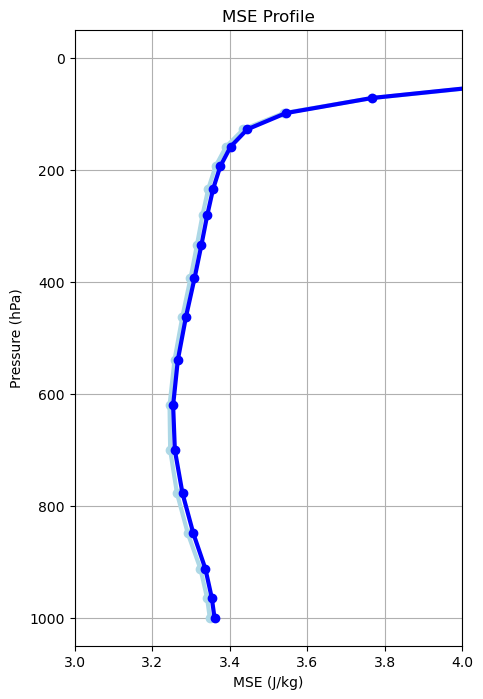

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming pressure levels in hPa (from surface to upper atmosphere)
plev = np.array([1.86630070e-02, 6.40212917e-02, 1.79125004e-01, 4.27986145e-01,
       9.21582565e-01, 1.84411835e+00, 3.52771545e+00, 6.61717712e+00,
       1.18538770e+01, 2.02301465e+01, 3.29760474e+01, 5.00729688e+01,
       7.18948193e+01, 9.87679492e+01, 1.27782412e+02, 1.58796006e+02,
       1.93727734e+02, 2.34129648e+02, 2.80582852e+02, 3.33600508e+02,
       3.93880430e+02, 4.62262422e+02, 5.39191211e+02, 6.20207773e+02,
       7.00365469e+02, 7.77501484e+02, 8.48955156e+02, 9.11984844e+02,
       9.63361797e+02, 9.99349922e+02])  # Example pressure levels

# Plot vertical profile
plt.figure(figsize=(5, 8))
plt.plot(a, plev, lw=3, marker='o', linestyle='-', color='lightblue')
plt.plot(b, plev, lw=3, marker='o', linestyle='-', color='blue')

# Reverse y-axis so that surface is at the bottom and upper atmosphere is at the top
plt.gca().invert_yaxis()

# Labels and title
plt.xlabel("MSE (J/kg)")
plt.ylabel("Pressure (hPa)")
plt.title("MSE Profile")
plt.grid()
plt.xlim(3, 4)
#plt.yscale('log')
# Show plot
plt.show()
